In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Global_Superstore2.csv", encoding="latin1", sep=',', quotechar='"', on_bad_lines='skip')

df.head()

/tmp/ipykernel_694/2799310426.py:5: DtypeWarning: Columns (0,11,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Global_Superstore2.csv", encoding="latin1", sep=',', quotechar='"', on_bad_lines='skip')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7.0,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9.0,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9.0,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5.0,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8.0,0.0,311.5200,903.04,Critical


In [25]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Number of rows: 84823
Number of columns: 24

Column Names:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

Data Types:
Row ID             object
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
City               object
State              object
Country            object
Postal Code        object
Market             object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity          float64
Discount          float64
Profit            fl

In [26]:
df.describe()

,Sales,Quantity,Discount,Profit
count,84818.000000,84818.000000,84818.000000,84818.000000
mean,175.413557,3.291166,0.141101,19.241806
std,394.165521,2.182168,2.724439,138.471800
min,0.444000,0.000000,-786.744000,-6599.978000
25%,25.344000,2.000000,0.000000,-0.030000
50%,59.460000,3.000000,0.000000,7.200000
75%,152.496000,4.000000,0.200000,25.190200
max,22638.480000,14.000000,79.380000,8399.976000


In [27]:
high_sales = df[df["Sales"] > 1000]

print(high_sales.head())

  Row ID         Order ID  Order Date   Ship Date     Ship Mode Customer ID  \
0  32298   CA-2012-124891  31-07-2012  31-07-2012      Same Day    RH-19495   
1  26341    IN-2013-77878  05-02-2013  07-02-2013  Second Class    JR-16210   
2  25330    IN-2013-71249  17-10-2013  18-10-2013   First Class    CR-12730   
3  13524  ES-2013-1579342  28-01-2013  30-01-2013   First Class    KM-16375   
4  47221     SG-2013-4320  05-11-2013  06-11-2013      Same Day     RH-9495   

      Customer Name      Segment           City            State  ...  \
0       Rick Hansen     Consumer  New York City         New York  ...   
1     Justin Ritter    Corporate     Wollongong  New South Wales  ...   
2      Craig Reiter     Consumer       Brisbane       Queensland  ...   
3  Katherine Murray  Home Office         Berlin           Berlin  ...   
4       Rick Hansen     Consumer          Dakar            Dakar  ...   

         Product ID    Category Sub-Category  \
0   TEC-AC-10003033  Technology  Acces

In [28]:
technology = df[df["Category"] == "Technology"]

print(technology.head())

  Row ID         Order ID  Order Date   Ship Date     Ship Mode Customer ID  \
0  32298   CA-2012-124891  31-07-2012  31-07-2012      Same Day    RH-19495   
2  25330    IN-2013-71249  17-10-2013  18-10-2013   First Class    CR-12730   
3  13524  ES-2013-1579342  28-01-2013  30-01-2013   First Class    KM-16375   
4  47221     SG-2013-4320  05-11-2013  06-11-2013      Same Day     RH-9495   
5  22732    IN-2013-42360  28-06-2013  01-07-2013  Second Class    JM-15655   

      Customer Name      Segment           City            State  ...  \
0       Rick Hansen     Consumer  New York City         New York  ...   
2      Craig Reiter     Consumer       Brisbane       Queensland  ...   
3  Katherine Murray  Home Office         Berlin           Berlin  ...   
4       Rick Hansen     Consumer          Dakar            Dakar  ...   
5       Jim Mitchum    Corporate         Sydney  New South Wales  ...   

         Product ID    Category Sub-Category  \
0   TEC-AC-10003033  Technology  Acces

In [29]:
sorted_sales = df.sort_values(
    by="Sales",
    ascending=False
)

print(sorted_sales.head(10))

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
26266  33994  CA-2011-145317  18-03-2011  23-03-2011  Standard Class   
329    38123  CA-2013-118689  03-10-2013  10-10-2013  Standard Class   
28222  39450  CA-2014-140151  24-03-2014  26-03-2014     First Class   
11850  33920  CA-2014-127180  23-10-2014  25-10-2014     First Class   
290    35487  CA-2014-166709  18-11-2014  23-11-2014  Standard Class   
122    40336  CA-2013-117121  18-12-2013  22-12-2013  Standard Class   
45     35395  CA-2011-116904  23-09-2011  28-09-2011  Standard Class   
110    35574  US-2013-107440  17-04-2013  21-04-2013  Standard Class   
29441  39785  CA-2013-158841  02-02-2013  04-02-2013    Second Class   
127    37722  CA-2013-143714  24-05-2013  28-05-2013  Standard Class   

      Customer ID       Customer Name      Segment           City  \
26266    SM-20320         Sean Miller  Home Office   Jacksonville   
329      TC-20980        Tamara Chand    Corporate      Lafayette   


In [30]:
print("Mean Sales:", df["Sales"].mean())

print("Median Sales:", df["Sales"].median())

print("Mode Sales:")
print(df["Sales"].mode())

print("Standard Deviation:", df["Sales"].std())

Mean Sales: 175.4135572253531
Median Sales: 59.46
Mode Sales:
0    12.96
Name: Sales, dtype: float64
Standard Deviation: 394.1655209506518


In [31]:
category_sales = df.groupby("Category")["Sales"].mean()

print(category_sales)

Category
Bookcases            7.000000
Furniture          324.611166
Office Supplies     89.675378
Technology         375.036861
Name: Sales, dtype: float64


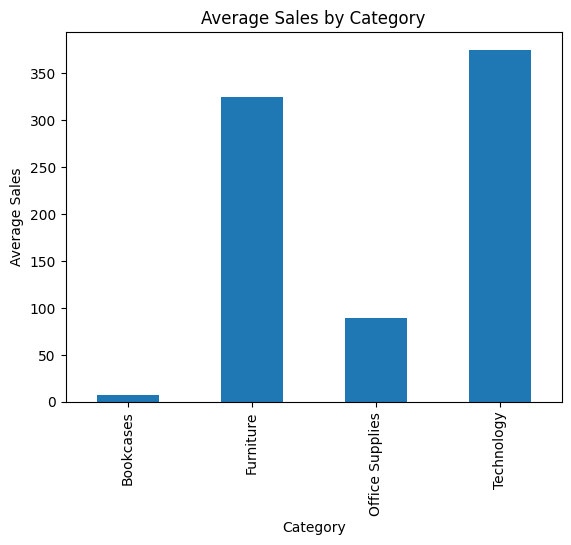

In [32]:
category_sales.plot(kind="bar")

plt.title("Average Sales by Category")
plt.xlabel("Category")
plt.ylabel("Average Sales")

plt.show()

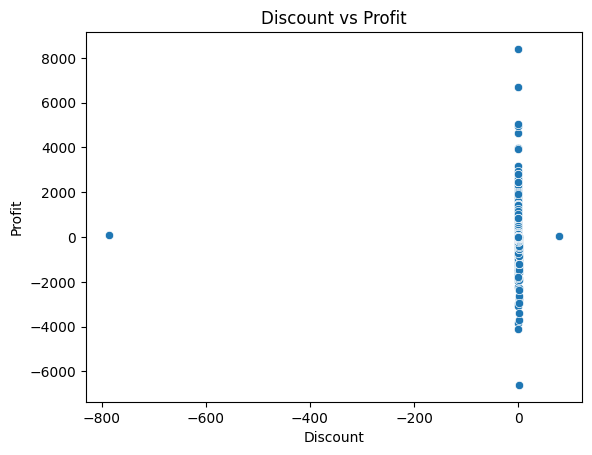

In [33]:
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

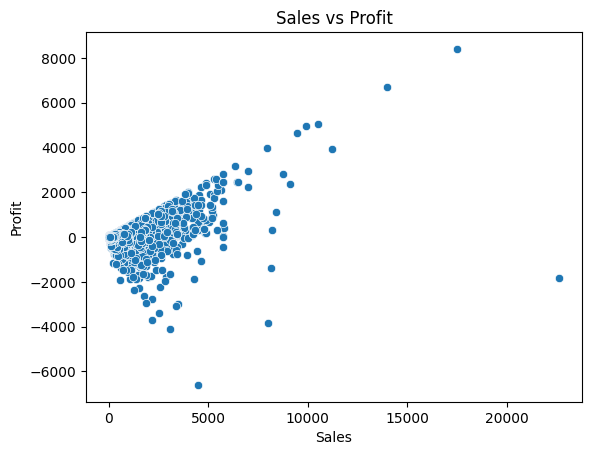

In [34]:
sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit"
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

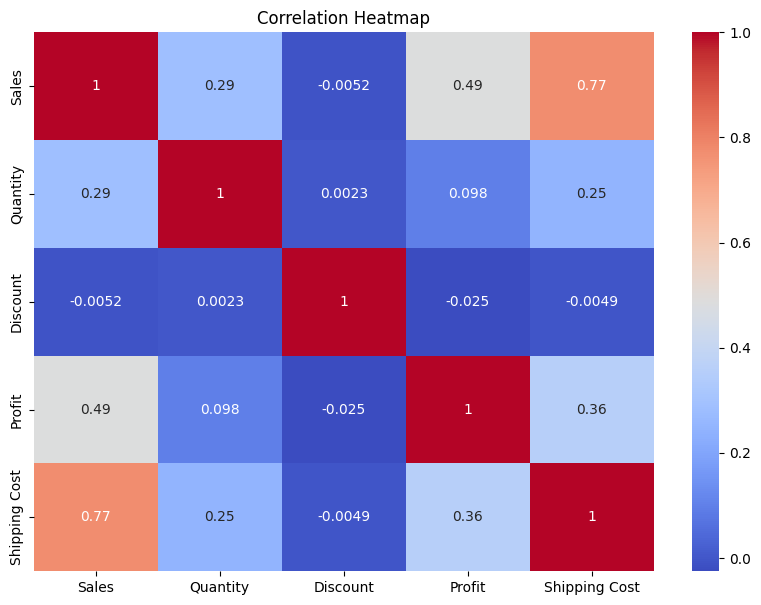

In [36]:
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Cost"
]

# Convert 'Shipping Cost' to numeric, coercing errors to NaN
df['Shipping Cost'] = pd.to_numeric(df['Shipping Cost'], errors='coerce')

# Fill NaN values with the median of 'Shipping Cost'
df['Shipping Cost'] = df['Shipping Cost'].fillna(df['Shipping Cost'].median())

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

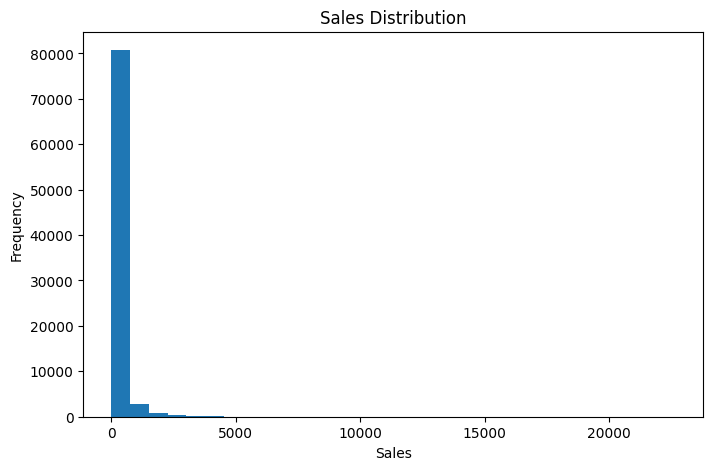

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Sales"],
    bins=30
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

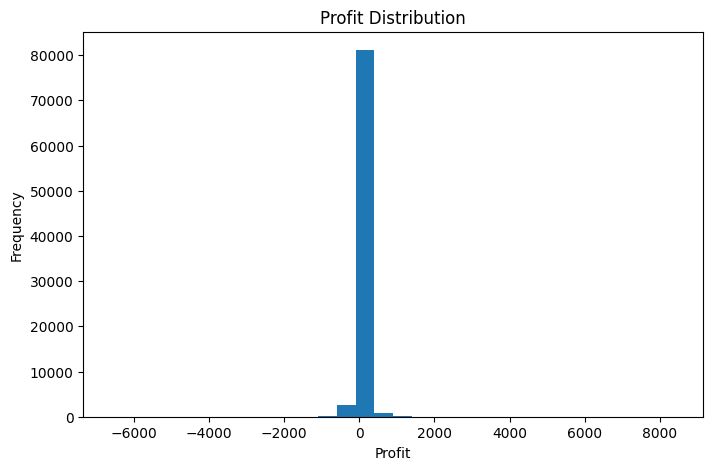

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Profit"],
    bins=30
)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

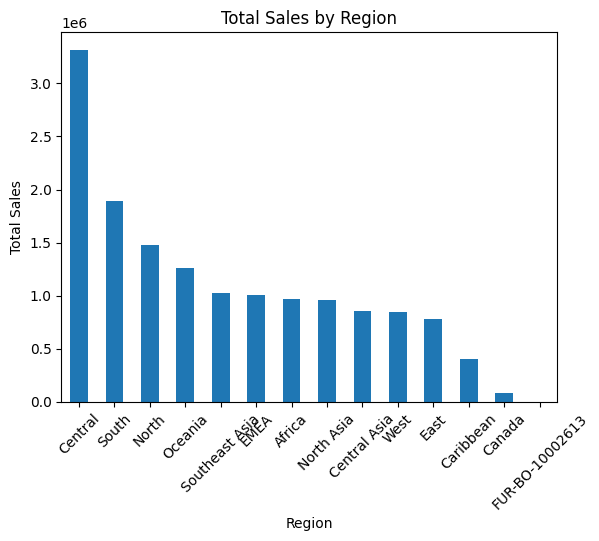

In [40]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.sort_values(ascending=False).plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()